In [17]:
# Import the pandas library
import pandas as pd

# Load the CSV file into a Pandas DataFrame
df = pd.read_csv('Housing.csv')

In [18]:
# Display the first 10 rows of the dataset
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [19]:
# df.shape returns a tuple: (number_of_rows, number_of_columns)
rows, columns = df.shape

print(f"Total rows: {rows}")
print(f"Total columns: {columns}")

Total rows: 545
Total columns: 13


In [20]:
# The target column is usually named 'price' in this dataset
target = 'price'

# The features are all the other columns except the target
features = df.columns.drop(target).tolist()

print(f"Target Column: '{target}'\n")
print("Feature Columns:")
print(features)

Target Column: 'price'

Feature Columns:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [21]:
# .isnull() checks each cell for missing data, and .sum() adds them up per column
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [22]:
# 1. Handle missing values
df = df.dropna()

# 2. Remove duplicate rows
df = df.drop_duplicates()

# 3. Convert categorical columns to numeric using one-hot encoding
df = pd.get_dummies(df, drop_first=True)

# 4. Keep only meaningful columns
print(f"Data shape after cleaning: {df.shape}")
df.head()

Data shape after cleaning: (545, 14)


,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [23]:
# Import necessary machine learning modules from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Separate the Features (X) from the Target (y)
X = df.drop('price', axis=1)
y = df['price']

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [24]:
# Import evaluation metrics and numpy for calculations
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Ask the trained model to predict prices for our 20% test data
y_pred = model.predict(X_test)

# Calculate the evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print the results formatted to 2 decimal places
print("--- Model Evaluation Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

--- Model Evaluation Metrics ---
Mean Absolute Error (MAE): 970,043.40
Root Mean Squared Error (RMSE): 1,324,506.96
R² Score: 0.6529


In [25]:
# Import the Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest model

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_y_pred = rf_model.predict(X_test)

# Calculate the evaluation metrics for Random Forest
rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))
rf_r2 = r2_score(y_test, rf_y_pred)

# Print a comparison of the two models
print("--- Model Performance Comparison ---")
print("1. Linear Regression:")
print(f"   MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | R²: {r2:.4f}\n")

print("2. Random Forest Regressor:")
print(f"   MAE: {rf_mae:,.2f} | RMSE: {rf_rmse:,.2f} | R²: {rf_r2:.4f}")

--- Model Performance Comparison ---
1. Linear Regression:
   MAE: 970,043.40 | RMSE: 1,324,506.96 | R²: 0.6529

2. Random Forest Regressor:
   MAE: 1,021,546.04 | RMSE: 1,400,565.97 | R²: 0.6119


Text(0, 0.5, 'Frequency')

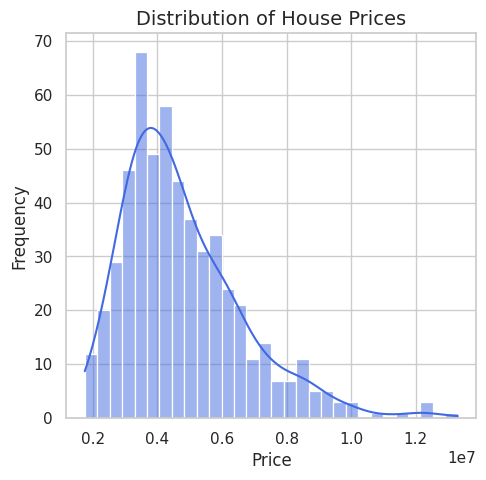

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# Create a figure to hold 3 subplots side-by-side
plt.figure(figsize=(18, 5))

# --- Chart 1: Histogram showing the distribution of house prices ---
plt.subplot(1, 3, 1)
sns.histplot(df['price'], kde=True, color='royalblue', bins=30)
plt.title('Distribution of House Prices', fontsize=14)
plt.xlabel('Price')
plt.ylabel('Frequency')



Text(0.5, 1.0, 'Top Features Correlated with Price')

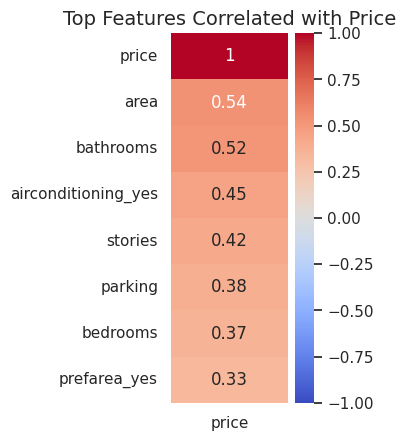

In [27]:
# --- Chart 2: Correlation heatmap ---
plt.subplot(1, 3, 2)
# We calculate correlations and isolate the 'price' column to see what drives it most
corr = df.corr()
sns.heatmap(corr[['price']].sort_values(by='price', ascending=False).head(8),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Top Features Correlated with Price', fontsize=14)



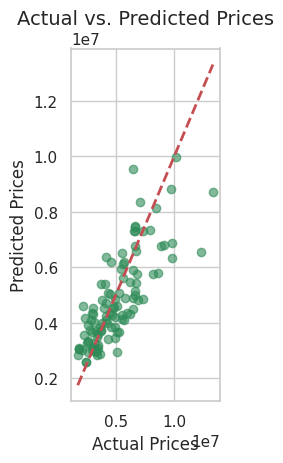

In [28]:
# --- Chart 3: Actual vs. Predicted price scatter plot (Random Forest) ---
plt.subplot(1, 3, 3)
plt.scatter(y_test, rf_y_pred, alpha=0.6, color='seagreen')
# Plot a red dashed diagonal line representing "perfect" predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Prices', fontsize=14)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

# Adjust layout and display the charts
plt.tight_layout()
plt.show()